# `agent/retrieval.py` — Validation Walkthrough

Exercises dependency-aware chunk retrieval against the indexed FE 501s manual.

Retrieval runs in two phases:
1. **Semantic search** — the query is embedded with `text-embedding-3-small` and the top-k
   matching chunks are fetched from ChromaDB.
2. **Dependency walk** — any `preparatory` chunk in the seed set has its `references` list
   followed recursively (BFS).  Referenced sections are fetched by exact section number
   and added to the result set with an incremented `depth`.

Results are returned sorted with the deepest prerequisites first, so the planner receives
chunks in the correct procedural sequence without additional sorting.

In [1]:
import sys
sys.path.insert(0, "..")

from dotenv import load_dotenv
load_dotenv("../.env")

from openai import OpenAI
from agent.retrieval import retrieve, open_collection

MANUAL = "FE_501s_2026_US_en_Bundle_RM_069969-000001_05sq_m1du"

col    = open_collection("../data/chroma")
client = OpenAI()

print(f"Collection: {col.count()} chunks indexed")

Collection: 600 chunks indexed


## 1. Basic semantic search (no dependency walk)

A query with no preparatory results — only the semantic seed set is returned.

In [2]:
chunks = retrieve(
    "change engine oil and oil filter",
    col, client,
    manual=MANUAL,
    n_results=3,
)

print(f"{len(chunks)} chunks returned\n")
print(f"{'depth':<6} {'section':<10} {'phase':<14} {'title'}")
print("-" * 70)
for c in chunks:
    print(f"{c.depth:<6} {c.section:<10} {c.phase or '(full)':<14} {c.section_title}")

3 chunks returned

depth  section    phase          title
----------------------------------------------------------------------
0      18.3.3     (full)         
0      22.3       (full)         
0      22.5       main           Checking the oil pressure


## 2. Dependency walk — fork disassembly

Querying for section 6.12 (Disassembling the piston rod) triggers the dependency walk:
- 6.12 preparatory references 6.10 and 6.11
- Those prerequisite sections are fetched at `depth=1`
- Result is sorted: deepest prerequisites first

In [3]:
chunks = retrieve(
    "disassembling the fork cartridge",
    col, client,
    manual=MANUAL,
    n_results=5,
)

print(f"{len(chunks)} chunks returned\n")
print(f"{'depth':<6} {'section':<10} {'phase':<14} {'title'}")
print("-" * 70)
for c in chunks:
    print(f"{c.depth:<6} {c.section:<10} {c.phase or '(full)':<14} {c.section_title}")

depth_0 = [c.section for c in chunks if c.depth == 0]
depth_1 = [c.section for c in chunks if c.depth == 1]
print(f"\nDirect matches (depth 0):   {sorted(set(depth_0))}")
print(f"Prerequisites  (depth 1):   {sorted(set(depth_1))}")

9 chunks returned

depth  section    phase          title
----------------------------------------------------------------------
1      6.11       (full)         Disassembling the cartridge
1      6.11       main           Disassembling the cartridge
1      6.12       (full)         Disassembling the piston rod
1      6.12       main           Disassembling the piston rod
0      6.10       (full)         Disassembling the fork legs
0      6.11       preparatory    Disassembling the cartridge
0      6.12       preparatory    Disassembling the piston rod
0      6.13       preparatory    
0      6.14       preparatory    Disassembling the gasket support

Direct matches (depth 0):   ['6.10', '6.11', '6.12', '6.13', '6.14']
Prerequisites  (depth 1):   ['6.11', '6.12']


## 3. Deep dependency chain — rear shock overhaul

Rear shock sub-procedures (9.12, 9.13) each require the shock absorber to be removed
first (9.9).  This exercises a multi-hop dependency chain.

In [4]:
chunks = retrieve(
    "disassembling the rear shock absorber",
    col, client,
    manual=MANUAL,
    n_results=5,
)

print(f"{len(chunks)} chunks returned\n")
print(f"{'depth':<6} {'section':<10} {'phase':<14} {'title'}")
print("-" * 70)
for c in chunks:
    print(f"{c.depth:<6} {c.section:<10} {c.phase or '(full)':<14} {c.section_title}")

max_depth = max(c.depth for c in chunks)
print(f"\nMax dependency depth: {max_depth}")

5 chunks returned

depth  section    phase          title
----------------------------------------------------------------------
0      9.13       (full)         Spring, removing
0      9.14       main           Damper, disassembling
0      9.15       main           Disassembling the piston rod
0      9.26       main           Removing the link fork
0      9.9        (full)         Removing the shock absorber

Max dependency depth: 0


## 4. Image paths in results

Images are linked to chunks by page number at index time.  The retrieval layer
deduplicates paths across the result set so the planner sees each image once,
even when the same page contributes to multiple sections.

In [5]:
chunks = retrieve(
    "adjusting handlebar position",
    col, client,
    manual=MANUAL,
    n_results=5,
)

all_images = [p for c in chunks for p in c.image_paths]
print(f"{len(chunks)} chunks, {len(all_images)} image paths total (deduplicated)\n")

for c in chunks:
    if c.image_paths:
        print(f"Section {c.section} [{c.phase or 'full'}] — {len(c.image_paths)} image(s)")
        for p in c.image_paths:
            print(f"  {p}")

5 chunks, 8 image paths total (deduplicated)

Section 16.1 [full] — 2 image(s)
  data/images/FE_501s_2026_US_en_Bundle_RM_069969-000001_05sq_m1du/p0155_00.jpg
  data/images/FE_501s_2026_US_en_Bundle_RM_069969-000001_05sq_m1du/p0155_01.jpg
Section 7.1 [full] — 2 image(s)
  data/images/FE_501s_2026_US_en_Bundle_RM_069969-000001_05sq_m1du/p0050_00.jpg
  data/images/FE_501s_2026_US_en_Bundle_RM_069969-000001_05sq_m1du/p0050_01.jpg
Section 7.2 [full] — 1 image(s)
  data/images/FE_501s_2026_US_en_Bundle_RM_069969-000001_05sq_m1du/p0051_00.jpg
Section 7.6 [main] — 3 image(s)
  data/images/FE_501s_2026_US_en_Bundle_RM_069969-000001_05sq_m1du/p0053_00.jpg
  data/images/FE_501s_2026_US_en_Bundle_RM_069969-000001_05sq_m1du/p0054_00.jpg
  data/images/FE_501s_2026_US_en_Bundle_RM_069969-000001_05sq_m1du/p0054_01.jpg


p0155_00.jpg


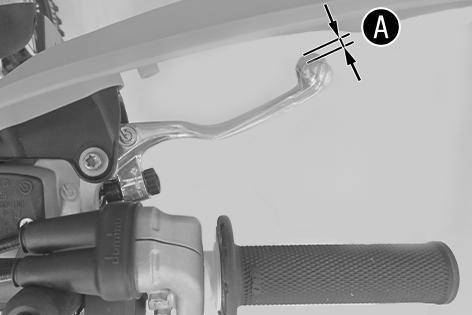

p0155_01.jpg


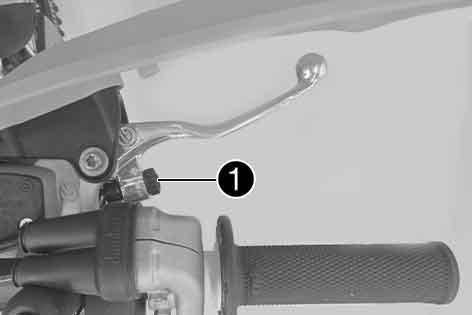

p0050_00.jpg


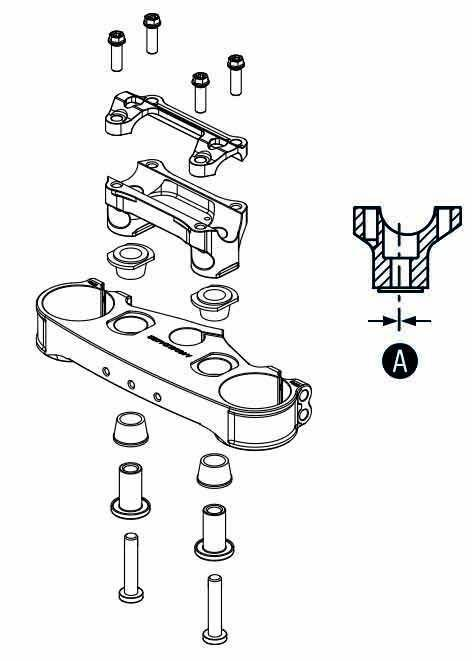

p0050_01.jpg


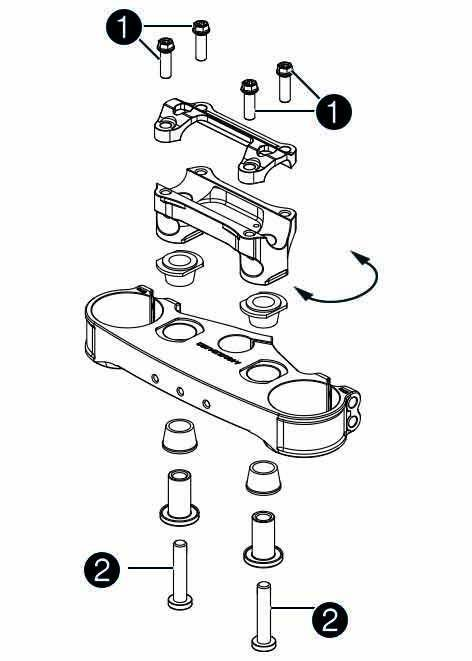

In [6]:
from pathlib import Path
from IPython.display import display, Image as IPImage

for img_path in all_images[:4]:
    p = Path("..") / img_path
    if p.exists():
        print(p.name)
        display(IPImage(str(p), width=400))

## 5. Torque specs surfaced through retrieval

Torque specs are stored on each chunk at index time and come back with every
retrieval result — the planner can pull them directly without a second query.

In [7]:
chunks = retrieve(
    "adjusting handlebar position",
    col, client,
    manual=MANUAL,
    n_results=5,
)

# Deduplicate specs by (bolt, nm) across all returned chunks
seen_specs: set[tuple] = set()
all_specs = []
for c in chunks:
    for spec in c.torque_specs:
        key = (spec["bolt"], spec["nm"])
        if key not in seen_specs:
            seen_specs.add(key)
            all_specs.append((c.section, spec))

if all_specs:
    print(f"{'Section':<10} {'Bolt':<12} {'Nm':>6}  {'ft·lbf':>7}  Note")
    print("-" * 65)
    for section, s in all_specs:
        print(f"{section:<10} {s['bolt']:<12} {s['nm']:>6}  {s['ftlbf']:>7}  {s['note']}")
else:
    print("No torque specs in this result set.")

Section    Bolt             Nm   ft·lbf  Note
-----------------------------------------------------------------
7.2        M10            40.0     29.5  Loctite® 243
7.2        M8             20.0     14.8  Make sure the installed gap widths are even.


## 6. Result ordering verification

The result list must be sorted with the deepest prerequisites first so the planner
can sequence steps without additional sorting.  Verify that `depth` is non-increasing
from the start of the list.

In [8]:
test_queries = [
    "disassembling the fork cartridge",
    "remove the rear shock absorber",
    "valve clearance adjustment",
    "change engine oil and oil filter",
]

print(f"{'Query':<45} {'Chunks':>6}  {'Max depth':>9}  Ordered?")
print("-" * 72)
for q in test_queries:
    results = retrieve(q, col, client, manual=MANUAL, n_results=5)
    depths  = [c.depth for c in results]
    ordered = depths == sorted(depths, reverse=True)
    print(f"{q[:45]:<45} {len(results):>6}  {max(depths) if depths else 0:>9}  {'✓' if ordered else '✗'}")

Query                                         Chunks  Max depth  Ordered?
------------------------------------------------------------------------
disassembling the fork cartridge                   9          1  ✓
remove the rear shock absorber                     5          0  ✓
valve clearance adjustment                         5          0  ✓
change engine oil and oil filter                   6          1  ✓
